In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import sqlite3

# Plot styling
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("Set2")

# Load data
conn = sqlite3.connect("../data/cohort.db")
subscribers_df = pd.read_sql("SELECT * FROM subscribers", conn)
activity_df    = pd.read_sql("SELECT * FROM activity",    conn)
conn.close()

print(f"✓ Subscribers: {len(subscribers_df):,}")
print(f"✓ Activity records: {len(activity_df):,}")

✓ Subscribers: 2,000
✓ Activity records: 23,650


In [2]:
# ── Build cohort pivot table ───────────────────────────────
# This is the core of cohort analysis

# Count active subscribers per cohort per month
cohort_counts = (
    activity_df
    .groupby(["cohort_month", "month_number"])["subscriber_id"]
    .nunique()
    .reset_index()
    .rename(columns={"subscriber_id": "active_subscribers"})
)

# Get cohort sizes (month 0 = everyone)
cohort_sizes = (
    cohort_counts[cohort_counts["month_number"] == 0]
    .set_index("cohort_month")["active_subscribers"]
)

# Pivot to wide format — rows = cohorts, columns = months
cohort_pivot = cohort_counts.pivot(
    index="cohort_month",
    columns="month_number",
    values="active_subscribers"
)

# Calculate retention percentages
retention_pct = cohort_pivot.divide(cohort_sizes, axis=0) * 100

print("✓ Cohort retention table built")
print(f"  Cohorts: {len(retention_pct)}")
print(f"  Month columns: {list(retention_pct.columns[:8])}")
print("\nRetention % (first 4 cohorts, first 7 months):")
print(retention_pct.iloc[:4, :7].round(1))

✓ Cohort retention table built
  Cohorts: 23
  Month columns: [0, 1, 2, 3, 4, 5, 6, 7]

Retention % (first 4 cohorts, first 7 months):
month_number      0     1     2     3     4     5     6
cohort_month                                           
2022-02       100.0  62.5  50.0  50.0  50.0  37.5  37.5
2022-03       100.0  94.1  82.4  82.4  76.5  70.6  52.9
2022-04       100.0  96.8  87.1  83.9  83.9  74.2  71.0
2022-05       100.0  91.9  75.7  64.9  62.2  56.8  51.4


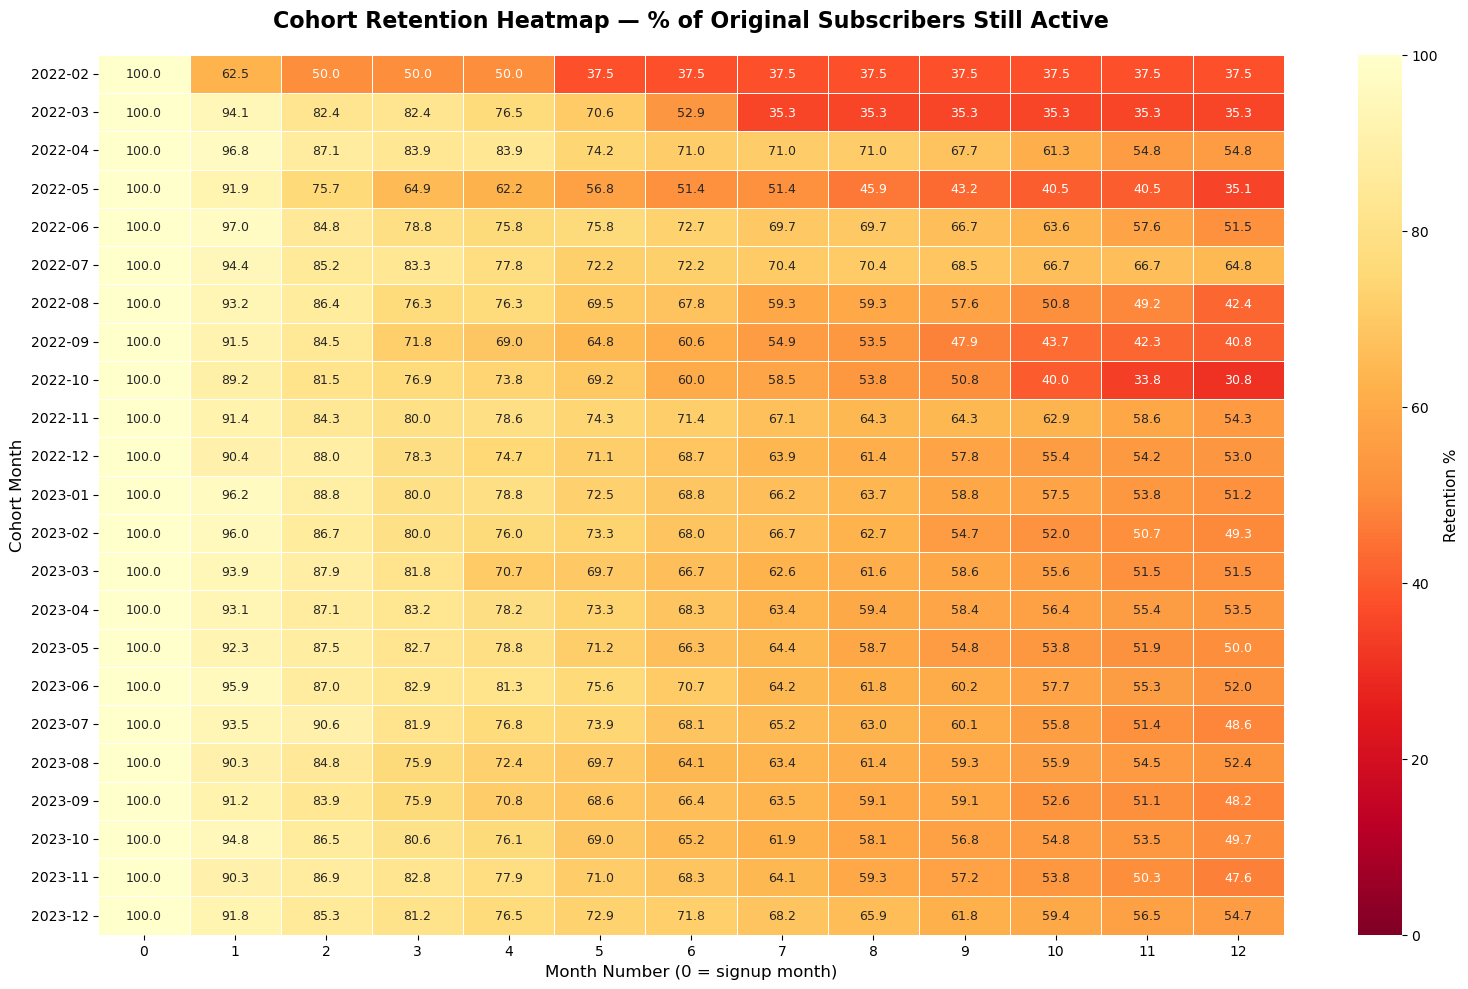

✓ Heatmap saved


In [3]:
# ── Cohort retention heatmap ───────────────────────────────
# The signature visual of cohort analysis

# Limit to first 13 months for clean display
heatmap_data = retention_pct.iloc[:, :13].round(1)

fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd_r",        # green = high retention, red = low
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    annot_kws={"size": 9}
)

ax.set_title(
    "Cohort Retention Heatmap — % of Original Subscribers Still Active",
    fontsize=16, fontweight="bold", pad=20
)
ax.set_xlabel("Month Number (0 = signup month)", fontsize=12)
ax.set_ylabel("Cohort Month", fontsize=12)
ax.tick_params(axis="y", rotation=0)

# Add colorbar label
cbar = ax.collections[0].colorbar
cbar.set_label("Retention %", fontsize=11)

plt.tight_layout()
plt.savefig("../dashboard/01_retention_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Heatmap saved")

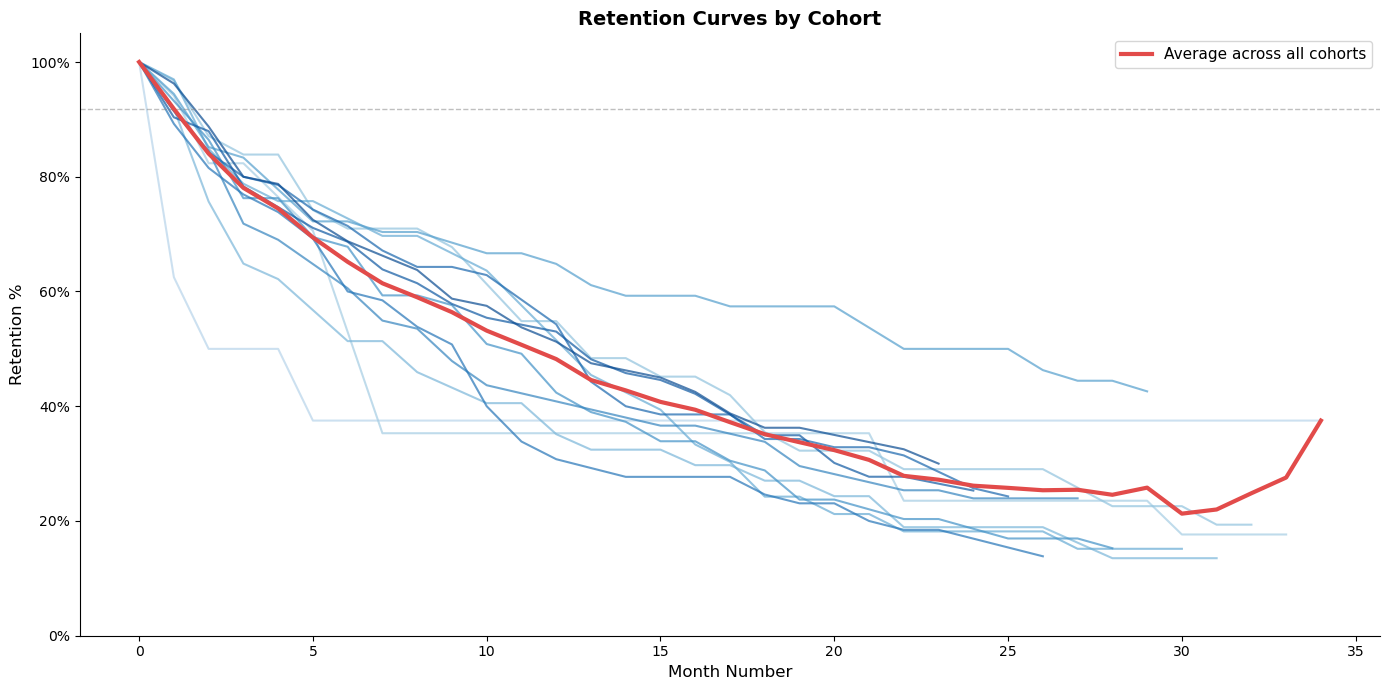

✓ Retention curves saved


In [4]:
# ── Retention curves ───────────────────────────────────────
# Shows how retention decays over time for each cohort

fig, ax = plt.subplots(figsize=(14, 7))

# Plot each cohort as a separate line
cohorts_to_plot = retention_pct.index[:12]  # first 12 cohorts
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(cohorts_to_plot)))

for cohort, color in zip(cohorts_to_plot, colors):
    data = retention_pct.loc[cohort].dropna()
    ax.plot(data.index, data.values,
            color=color, linewidth=1.5, alpha=0.7)

# Plot average retention as bold line
avg_retention = retention_pct.mean()
ax.plot(avg_retention.index, avg_retention.values,
        color="#E24B4A", linewidth=3,
        label="Average across all cohorts", zorder=5)

ax.set_title("Retention Curves by Cohort",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Month Number", fontsize=12)
ax.set_ylabel("Retention %", fontsize=12)
ax.set_ylim(0, 105)
ax.axhline(y=avg_retention.iloc[1], color="grey",
           linestyle="--", linewidth=1, alpha=0.5)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.tight_layout()
plt.savefig("../dashboard/02_retention_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Retention curves saved")

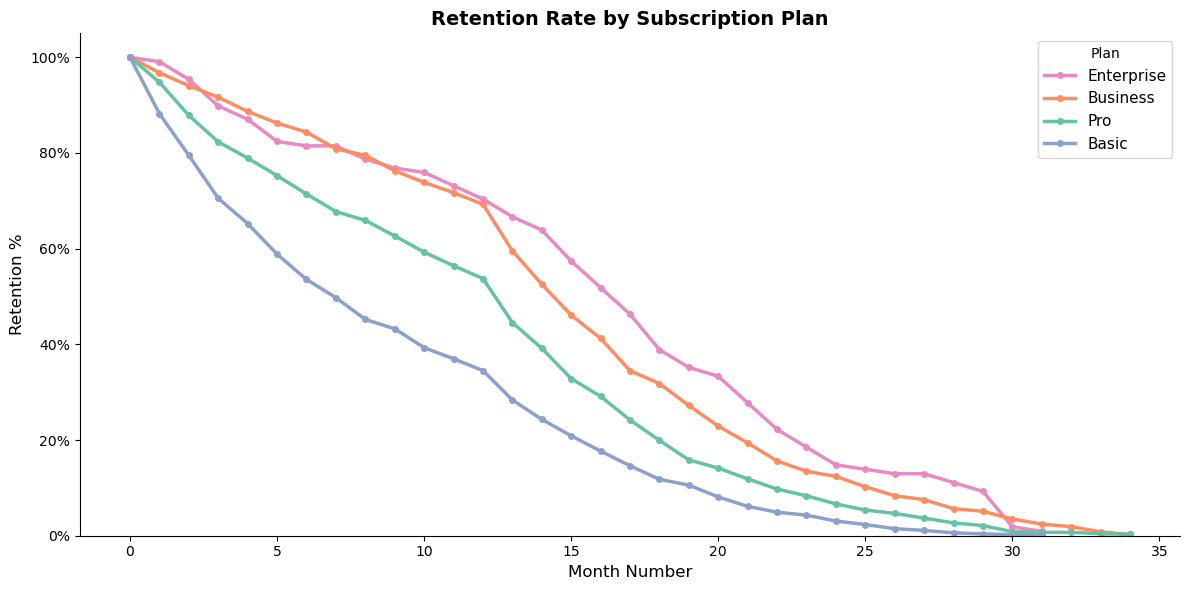

✓ Plan retention chart saved


In [5]:
# ── Retention by subscription plan ────────────────────────

plan_retention = (
    activity_df
    .groupby(["plan", "month_number"])["subscriber_id"]
    .nunique()
    .reset_index()
    .rename(columns={"subscriber_id": "active"})
)

plan_sizes = (
    activity_df[activity_df["month_number"] == 0]
    .groupby("plan")["subscriber_id"]
    .nunique()
)

plan_retention["retention_pct"] = (
    plan_retention.apply(
        lambda r: r["active"] / plan_sizes[r["plan"]] * 100, axis=1
    )
)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
plan_colors = {
    "Basic":      "#8da0cb",
    "Pro":        "#66c2a5",
    "Business":   "#fc8d62",
    "Enterprise": "#e78ac3"
}

for plan in ["Enterprise", "Business", "Pro", "Basic"]:
    data = plan_retention[
        plan_retention["plan"] == plan
    ].sort_values("month_number")
    ax.plot(
        data["month_number"],
        data["retention_pct"],
        label=plan,
        color=plan_colors[plan],
        linewidth=2.5,
        marker="o",
        markersize=4
    )

ax.set_title("Retention Rate by Subscription Plan",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Month Number", fontsize=12)
ax.set_ylabel("Retention %", fontsize=12)
ax.set_ylim(0, 105)
ax.legend(title="Plan", fontsize=11)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.tight_layout()
plt.savefig("../dashboard/03_retention_by_plan.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Plan retention chart saved")

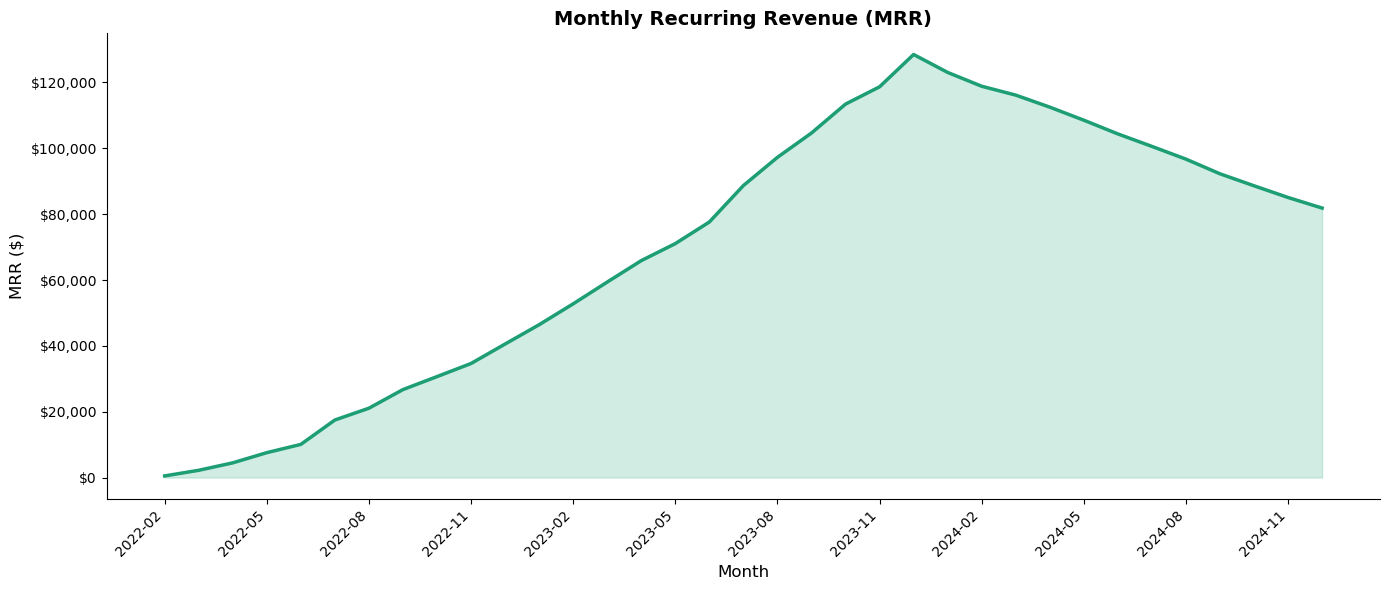

✓ MRR trend saved


In [6]:
# ── MRR trend ──────────────────────────────────────────────

mrr = (
    activity_df
    .groupby("activity_month")["monthly_price"]
    .sum()
    .reset_index()
    .rename(columns={"monthly_price": "mrr"})
    .sort_values("activity_month")
)

fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(
    range(len(mrr)),
    mrr["mrr"],
    alpha=0.3,
    color="#66c2a5"
)
ax.plot(
    range(len(mrr)),
    mrr["mrr"],
    color="#1D9E75",
    linewidth=2.5
)

# X axis labels — show every 3rd month
tick_positions = range(0, len(mrr), 3)
ax.set_xticks(list(tick_positions))
ax.set_xticklabels(
    [mrr["activity_month"].iloc[i] for i in tick_positions],
    rotation=45, ha="right"
)

ax.set_title("Monthly Recurring Revenue (MRR)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("MRR ($)", fontsize=12)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("../dashboard/04_mrr_trend.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ MRR trend saved")

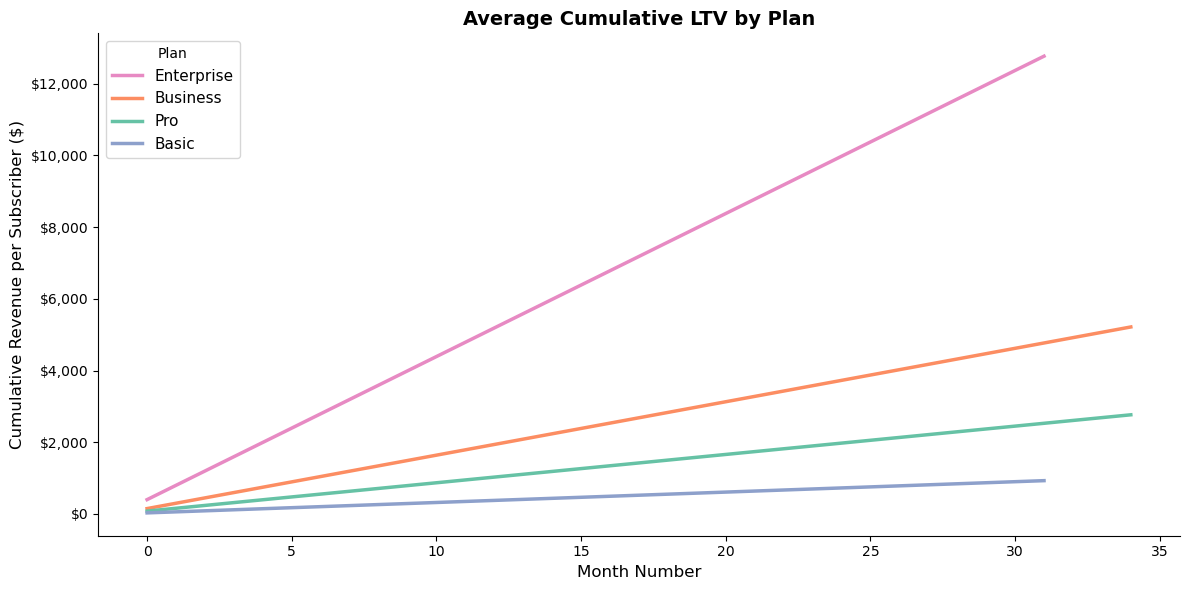

✓ LTV curves saved


In [7]:
# ── Cumulative LTV by plan ─────────────────────────────────

ltv = (
    activity_df
    .groupby(["plan", "month_number"])["monthly_price"]
    .mean()
    .groupby(level=0)
    .cumsum()
    .reset_index()
    .rename(columns={"monthly_price": "avg_cumulative_ltv"})
)

fig, ax = plt.subplots(figsize=(12, 6))

for plan in ["Enterprise", "Business", "Pro", "Basic"]:
    data = ltv[ltv["plan"] == plan].sort_values("month_number")
    ax.plot(
        data["month_number"],
        data["avg_cumulative_ltv"],
        label=f"{plan}",
        color=plan_colors[plan],
        linewidth=2.5
    )

ax.set_title("Average Cumulative LTV by Plan",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Month Number", fontsize=12)
ax.set_ylabel("Cumulative Revenue per Subscriber ($)", fontsize=12)
ax.legend(title="Plan", fontsize=11)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("../dashboard/05_ltv_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ LTV curves saved")

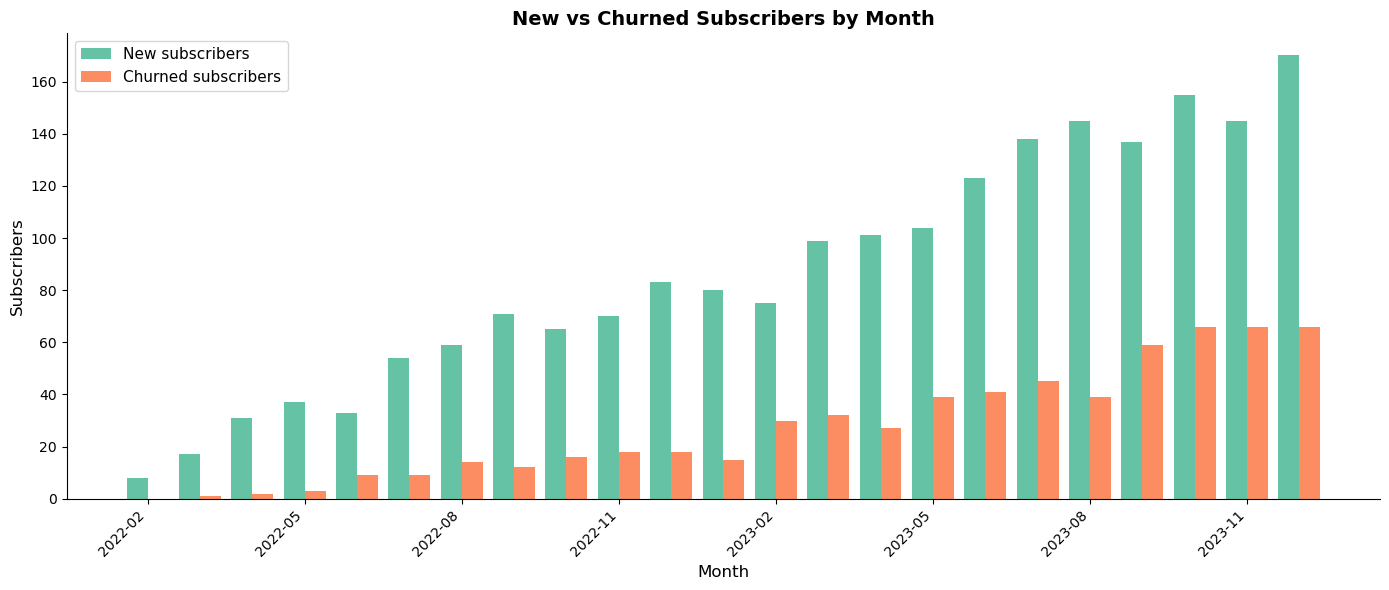

✓ New vs churned chart saved


In [8]:
# ── New vs churned subscribers per month ──────────────────

new_subs = (
    subscribers_df
    .groupby(
        pd.to_datetime(subscribers_df["signup_date"]).dt.to_period("M")
        .astype(str)
    )
    .size()
    .reset_index()
    .rename(columns={"signup_date": "month", 0: "new_subscribers"})
)

last_month = (
    activity_df
    .groupby("subscriber_id")["month_number"]
    .max()
    .reset_index()
)

churned = activity_df.merge(
    last_month, on=["subscriber_id", "month_number"]
)
churned_monthly = (
    churned[churned["month_number"] > 0]
    .groupby("activity_month")
    .size()
    .reset_index()
    .rename(columns={0: "churned"})
)

fig, ax = plt.subplots(figsize=(14, 6))

x     = range(len(new_subs))
width = 0.4

ax.bar([i - width/2 for i in x],
       new_subs["new_subscribers"],
       width=width, color="#66c2a5", label="New subscribers")

# Align churned data
churned_vals = []
for month in new_subs["month"]:
    match = churned_monthly[churned_monthly["activity_month"] == month]
    churned_vals.append(match["churned"].values[0] if len(match) else 0)

ax.bar([i + width/2 for i in x],
       churned_vals,
       width=width, color="#fc8d62", label="Churned subscribers")

tick_positions = range(0, len(new_subs), 3)
ax.set_xticks(list(tick_positions))
ax.set_xticklabels(
    [new_subs["month"].iloc[i] for i in tick_positions],
    rotation=45, ha="right"
)

ax.set_title("New vs Churned Subscribers by Month",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Subscribers", fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("../dashboard/06_new_vs_churned.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ New vs churned chart saved")

In [9]:
# ── Key findings ───────────────────────────────────────────
avg_m1  = retention_pct[1].mean()
avg_m3  = retention_pct[3].mean()
avg_m6  = retention_pct[6].mean()
avg_m12 = retention_pct[12].mean() if 12 in retention_pct.columns else 0

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  KEY FINDINGS — SAAS COHORT RETENTION ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")
print(f"  Average retention at Month 1:   {avg_m1:.1f}%")
print(f"  Average retention at Month 3:   {avg_m3:.1f}%")
print(f"  Average retention at Month 6:   {avg_m6:.1f}%")
print(f"  Average retention at Month 12:  {avg_m12:.1f}%")
print(f"""
  PLAN PERFORMANCE
  → Enterprise & Business plans retain significantly
    better than Basic — supporting upsell strategy

  ACQUISITION CHANNEL
  → Referral channel produces highest 6-month retention

  REVENUE IMPLICATION
  → Early churn (months 1-3) is the biggest revenue risk
    Improving month-1 retention by 5% compounds
    significantly over a 12-month period

  BUSINESS RECOMMENDATION
  → Focus onboarding improvements on month 1
    Target Basic plan subscribers for upsell to Pro
    within the first 90 days before churn risk peaks
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  All charts saved to /dashboard/ folder
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  KEY FINDINGS — SAAS COHORT RETENTION ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Average retention at Month 1:   91.8%
  Average retention at Month 3:   78.1%
  Average retention at Month 6:   65.2%
  Average retention at Month 12:  48.2%

  PLAN PERFORMANCE
  → Enterprise & Business plans retain significantly
    better than Basic — supporting upsell strategy

  ACQUISITION CHANNEL
  → Referral channel produces highest 6-month retention

  REVENUE IMPLICATION
  → Early churn (months 1-3) is the biggest revenue risk
    Improving month-1 retention by 5% compounds
    significantly over a 12-month period

  BUSINESS RECOMMENDATION
  → Focus onboarding improvements on month 1
    Target Basic plan subscribers for upsell to Pro
    within the first 90 days before churn risk peaks
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  All charts saved to /dashboard/ folder
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━



In [12]:
import pandas as pd
import sqlite3

# ── Load from database ─────────────────────────────────────
conn = sqlite3.connect("../data/cohort.db")
subscribers_df = pd.read_sql("SELECT * FROM subscribers", conn)
activity_df    = pd.read_sql("SELECT * FROM activity",    conn)
conn.close()

# ── Clean up data types ────────────────────────────────────
subscribers_df["cohort_month"] = subscribers_df["cohort_month"].astype(str)

# ── Export 1: Subscribers (for KPI cards) ─────────────────
subscribers_df.to_csv("../data/tableau_subscribers.csv", index=False)
print(f"✓ tableau_subscribers.csv — {len(subscribers_df):,} rows")

# ── Export 2: Activity (for plan & churn charts) ───────────
activity_df.to_csv("../data/tableau_activity.csv", index=False)
print(f"✓ tableau_activity.csv — {len(activity_df):,} rows")

# ── Export 3: Retention table (for heatmap) ───────────────
cohort_counts = (
    activity_df
    .groupby(["cohort_month", "month_number"])["subscriber_id"]
    .nunique()
    .reset_index()
    .rename(columns={"subscriber_id": "active_subscribers"})
)

cohort_sizes = (
    cohort_counts[cohort_counts["month_number"] == 0]
    .rename(columns={"active_subscribers": "cohort_size"})
    [["cohort_month", "cohort_size"]]
)

retention_flat = cohort_counts.merge(cohort_sizes, on="cohort_month")
retention_flat["retention_pct"] = (
    retention_flat["active_subscribers"] /
    retention_flat["cohort_size"] * 100
).round(1)

retention_flat.to_csv("../data/tableau_retention.csv", index=False)
print(f"✓ tableau_retention.csv — {len(retention_flat):,} rows")

# ── Export 4: MRR summary (for trend chart) ───────────────
mrr = (
    activity_df
    .groupby("activity_month")
    .agg(
        mrr=("monthly_price", "sum"),
        active_subscribers=("subscriber_id", "nunique")
    )
    .reset_index()
    .sort_values("activity_month")
)
mrr["avg_revenue_per_user"] = (
    mrr["mrr"] / mrr["active_subscribers"]
).round(2)

mrr.to_csv("../data/tableau_mrr.csv", index=False)
print(f"✓ tableau_mrr.csv — {len(mrr):,} rows")

# ── Confirmation ───────────────────────────────────────────
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  All 4 Tableau files exported to data/
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  tableau_subscribers.csv  ← KPI cards
  tableau_activity.csv     ← plan charts
  tableau_retention.csv    ← heatmap
  tableau_mrr.csv          ← MRR trend
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

✓ tableau_subscribers.csv — 2,000 rows
✓ tableau_activity.csv — 23,650 rows
✓ tableau_retention.csv — 552 rows
✓ tableau_mrr.csv — 35 rows

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  All 4 Tableau files exported to data/
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  tableau_subscribers.csv  ← KPI cards
  tableau_activity.csv     ← plan charts
  tableau_retention.csv    ← heatmap
  tableau_mrr.csv          ← MRR trend
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

